In [547]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup Success")

Setup Success


In [548]:
data = pd.read_csv("../data/Mall_Customers.csv")

data.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [549]:
data.shape


(200, 5)

In [550]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [551]:
data.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [552]:
data.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

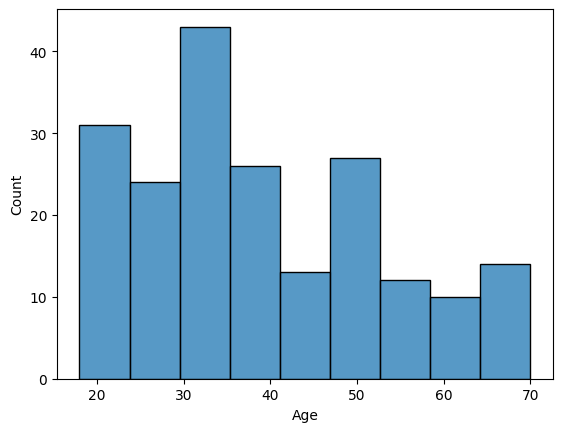

In [553]:
sns.histplot(data["Age"])

plt.show()


In [554]:
data.columns


Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [555]:
data.columns = data.columns.str.strip()
print(data.columns)


Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


In [556]:
print(data.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


In [557]:
data.columns = data.columns.str.strip()
print(data.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


In [558]:
data.columns = data.columns.str.strip()
data.columns = data.columns.str.replace(" ", "_")
data.columns = data.columns.str.replace("($)", "", regex=True)
data.columns = data.columns.str.replace("–", "_")
print(data.columns)


Index(['CustomerID', 'Gender', 'Age', 'Annual_Income_(k$)',
       'Spending_Score_(1-100)'],
      dtype='str')


In [559]:
for i in data.columns:
    print(i)
    

CustomerID
Gender
Age
Annual_Income_(k$)
Spending_Score_(1-100)


In [560]:
data.columns = data.columns.str.strip()
data.columns = data.columns.str.lower()
print(data.columns)

Index(['customerid', 'gender', 'age', 'annual_income_(k$)',
       'spending_score_(1-100)'],
      dtype='str')


In [561]:
print(data.columns.tolist())


['customerid', 'gender', 'age', 'annual_income_(k$)', 'spending_score_(1-100)']


In [562]:
data.columns = data.columns.str.strip()
print(data.columns)


Index(['customerid', 'gender', 'age', 'annual_income_(k$)',
       'spending_score_(1-100)'],
      dtype='str')


In [563]:
data = pd.read_csv("../data/Mall_Customers.csv")

print(data.columns)


Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


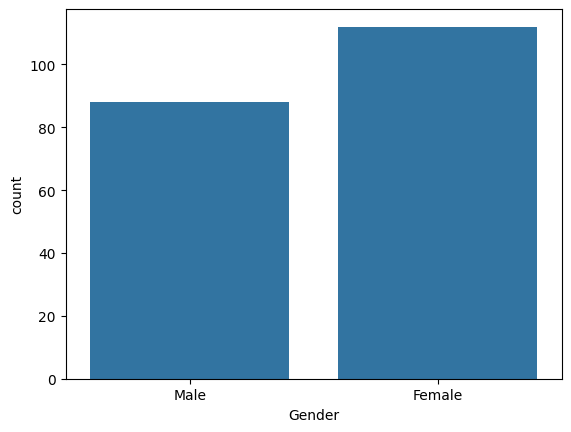

In [564]:
sns.countplot(x='Gender', data=data)

plt.show()

In [565]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [566]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [567]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

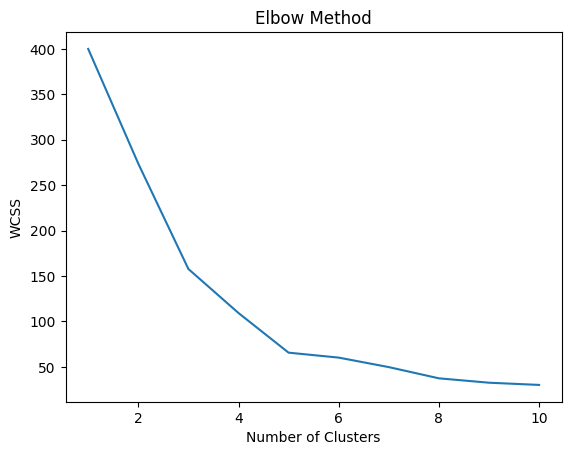

In [568]:
plt.plot(range(1,11), wcss)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [569]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

y = kmeans.fit_predict(X_scaled)

data['Cluster'] = y

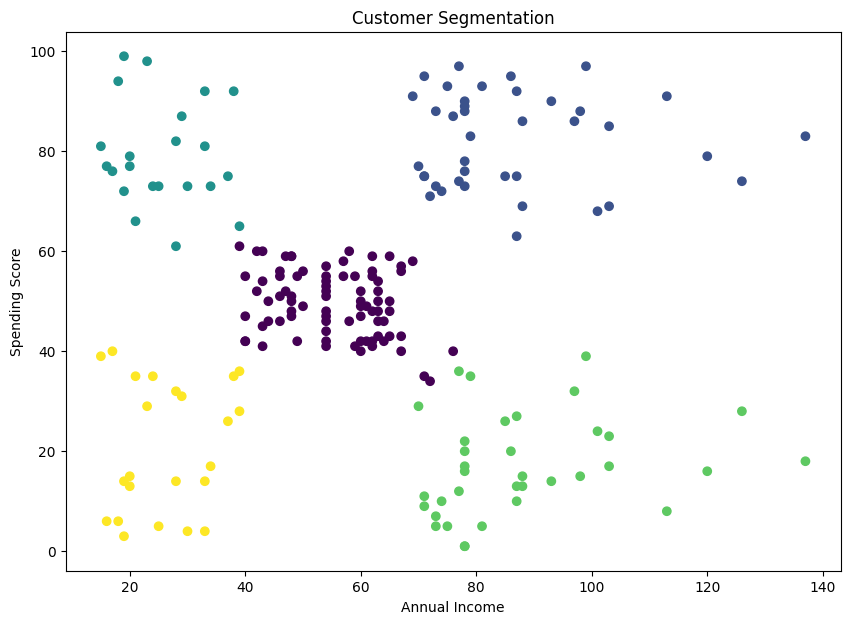

In [570]:
plt.figure(figsize=(10,7))

plt.scatter(
    data['Annual Income (k$)'],
    data['Spending Score (1-100)'],
    c=data['Cluster']
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Segmentation")

plt.show()

In [571]:
data.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


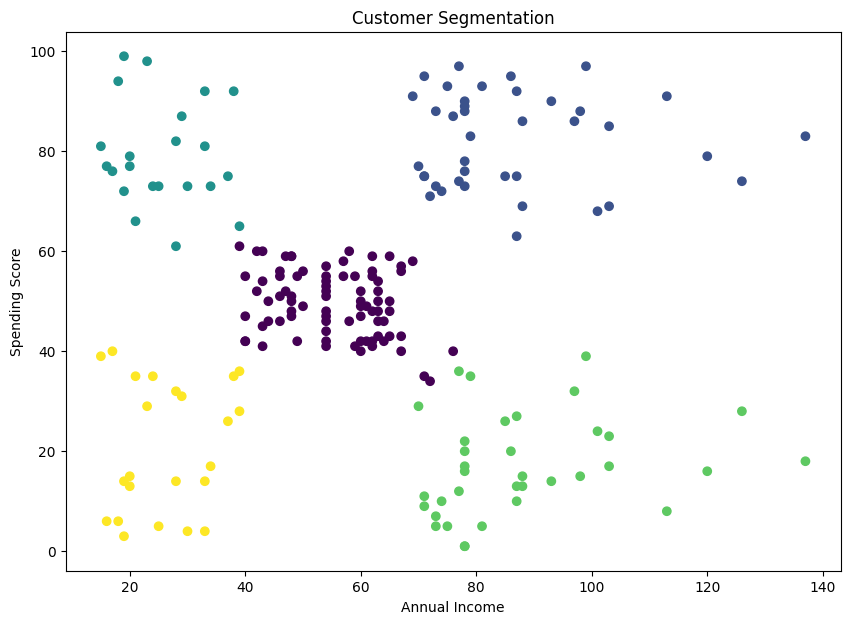

In [572]:
plt.figure(figsize=(10,7))

plt.scatter(
    data['Annual Income (k$)'],
    data['Spending Score (1-100)'],
    c=data['Cluster']
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Segmentation")

plt.savefig("../images/customer_segmentation.png")

plt.show()